In [82]:
import pandas as pd
import matplotlib.pyplot as plt

from expense_predictor.analyzer import (load_data,compute_monthly_totals,detect_large_transactions)
from expense_predictor.recommendations import generate_recommendations
from expense_predictor.predictor import predict_next
from expense_predictor.visualizer import plot_moving_average

In [106]:
# Adjust path relative to notebook location
df = load_data("../data/transactions_5.csv")

df.head()


Loading: ../data/transactions_5.csv
  Rows loaded: 1000

[date]
  ⚠  2 date(s) could not be parsed and were set to NaT.

[amount]
  ⚠  46 negative amount(s) replaced with NaN.
  ⚠  104 amount(s) could not be parsed and were set to NaN.
  ✔  Amount range after cleaning: 2.01 → 2442.54

[category]
  ✔  Unique categories after normalisation: 21

  ✔  Final shape: (1000, 3)
                       date category  amount
0 2025-01-01 00:00:00+00:00   Events   19.77
1 2025-01-01 00:00:00+00:00    Other  146.93
2 2025-01-01 02:27:00+00:00   Travel  281.89


,date,category,amount
0,2025-01-01 00:00:00+00:00,Events,19.77
1,2025-01-01 00:00:00+00:00,Other,146.93
2,2025-01-01 02:27:00+00:00,Travel,281.89
3,2025-01-01 09:57:54+00:00,Motel,129.72
4,2025-01-02 00:00:00+00:00,Rent,1116.13


In [107]:
monthly_totals = compute_monthly_totals(df)

monthly_totals

date
2025-01-31 00:00:00+00:00    10847.70
2025-02-28 00:00:00+00:00     5530.46
2025-03-31 00:00:00+00:00     5903.89
2025-04-30 00:00:00+00:00     8289.97
2025-05-31 00:00:00+00:00     9316.07
2025-06-30 00:00:00+00:00     8837.07
2025-07-31 00:00:00+00:00     7007.39
2025-08-31 00:00:00+00:00     7896.89
2025-09-30 00:00:00+00:00     8273.97
2025-10-31 00:00:00+00:00     9428.85
2025-11-30 00:00:00+00:00     6854.26
2025-12-31 00:00:00+00:00    14432.67
Freq: ME, Name: amount, dtype: float64

In [108]:
unusual = detect_large_transactions(df)

unusual


[detect_large_transactions]
  Mean: 114.68 | Std: 240.87 | Threshold (z>2.0): 596.42
  30 large transaction(s) detected out of 896 valid rows.


,date,category,amount,z_score
0,2025-05-18 00:00:00+00:00,Tech,2442.54,9.66
1,2025-12-05 02:46:41+00:00,Tech,2265.30,8.93
2,2025-12-18 23:18:14+00:00,Tech,2229.41,8.78
3,2025-07-26 00:00:00+00:00,Tech,2025.97,7.93
4,2025-11-08 00:00:00+00:00,Tech,1985.98,7.77
5,2025-10-09 00:00:00+00:00,Tech,1783.73,6.93
6,2025-09-16 15:29:56+00:00,Tech,1722.17,6.67
7,2025-10-05 00:00:00+00:00,Tech,1691.93,6.55
8,2025-12-27 00:00:00+00:00,Rent,1335.94,5.07
9,2025-01-28 00:00:00+00:00,Rent,1291.34,4.88


In [109]:
prediction = predict_next(monthly_totals)

print(f"Predicted next month spending: {prediction:.2f}")

Predicted next month spending: 10139.24


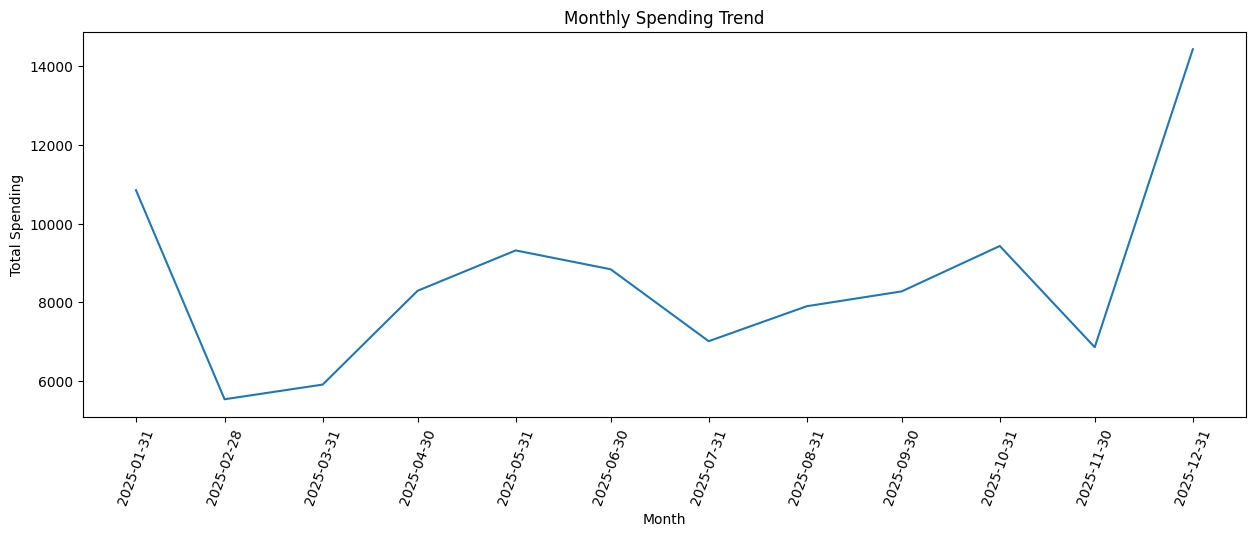

In [110]:
plt.figure(figsize=[15, 5])
plt.plot(monthly_totals.index, monthly_totals.values)
plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")
plt.xticks(ticks=monthly_totals.index, rotation=70)
plt.show()

In [111]:
recs = generate_recommendations(df)

for r in recs:
    print("-", r)

- You spend the most on 'Tech' ($24558.59). Consider reviewing this category to reduce expenses.
- Your average transaction amount is relatively high. Try to track small purchases more carefully.
- You spend across many categories. Creating a monthly budget could help manage spending.


In [64]:
plot_moving_average("../data/transactions_2.csv")

DataError: No numeric types to aggregate